# Thesis figure: T5Gemma2-4B Discord-Unveiled training loss curve

Plots the training loss and validation ROUGE-L for the headline Discord bootstrap run
(hint-full, +Molweni replay, from the Molweni checkpoint, `8e-6`, e5, b16 — the
best-performing arm of `tab:discord-results`, link F1 51.52). Separate from the Molweni
loss curve (`thesis_loss_curve.ipynb`). Output PNG -> thesis `media/`.

Validation loss is parsed but deliberately **not plotted**: nothing in the pipeline
selects on it (`load_best_model_at_end` is disabled in `train.py`, and inference always
loads the final checkpoint), so the thesis does not argue from it.

As with the Molweni notebook, many Discord runs errored out; this keeps only logs that
contain the final `train_runtime` summary and picks the most recent. Point `RUN_GLOB` at
a different arm to plot it.

In [1]:
import ast, glob, os, re
import matplotlib.pyplot as plt

LOG_ROOT = "../other-clusters"
OUT = "../../thesis/media/discord_loss.png"
# headline: hint-full, +Molweni replay, FROM Molweni ckpt, 8e-6, e5, b16 (link F1 51.52)
RUN_GLOB = "**/slurm/logs/*discord-unveiled-hintfull-molwenik1_natural2_seed27_8e-6_e5_b16*.out"

def _isnum(v):
    try:
        float(v); return True
    except (TypeError, ValueError):
        return False

def parse_log(path):
    train, evals, finished = [], [], False
    for line in open(path, errors="ignore"):
        line = line.strip()
        m = re.search(r"\{[^{}]*\}", line)
        if not m:
            continue
        try:
            d = ast.literal_eval(m.group(0))
        except Exception:
            continue
        if "train_runtime" in d:
            finished = True
        elif "eval_loss" in d:
            evals.append({k: float(v) for k, v in d.items() if _isnum(v)})
        elif "loss" in d:
            train.append({k: float(v) for k, v in d.items() if _isnum(v)})
    return train, evals, finished

cands = glob.glob(os.path.join(LOG_ROOT, RUN_GLOB), recursive=True)
done = [(p, *parse_log(p)[:2]) for p in cands if parse_log(p)[2]]
assert done, f"no completed run matched {RUN_GLOB}"
path, train, evals = sorted(done, key=lambda t: os.path.getmtime(t[0]))[-1]
print("using:", os.path.basename(path))
print(f"{len(train)} train points, {len(evals)} eval points")

using: 311568_t5gemma2-4b_train_discord-unveiled-hintfull-molwenik1_natural2_seed27_8e-6_e5_b16_s2000_newprompt_FROM_t5gemma2-4b_train_molweni_natural2_seed27_5e-6_e5_b16_s2000_newprompt.out
18 train points, 5 eval points


wrote ../../thesis/media/discord_loss.png


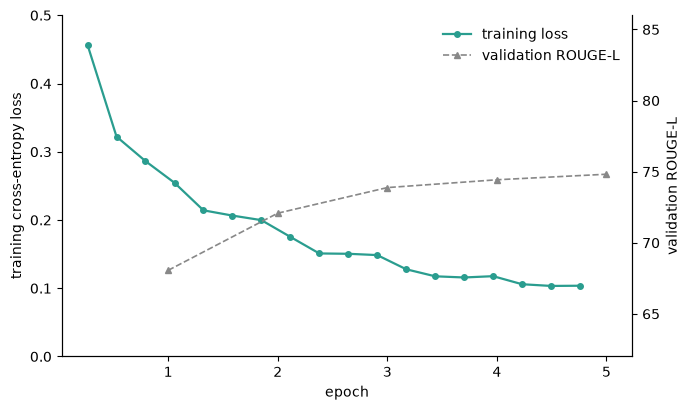

In [2]:
tr_x = [d["epoch"] for d in train]; tr_y = [d["loss"] for d in train]
ev_x = [d["epoch"] for d in evals]; ev_r = [d["eval_rougeL"] for d in evals]

fig, ax1 = plt.subplots(figsize=(7, 4.2))
teal, gray = "#2a9d8f", "#888888"
ax1.plot(tr_x, tr_y, "-o", color=teal, ms=4, lw=1.6, label="training loss")
ax1.set_xlabel("epoch"); ax1.set_ylabel("training cross-entropy loss")
ax1.set_xticks(range(0, 6)); ax1.spines["top"].set_visible(False)
ax2 = ax1.twinx()
ax2.plot(ev_x, ev_r, "--^", color=gray, ms=5, lw=1.2, label="validation ROUGE-L")
ax2.set_ylabel("validation ROUGE-L"); ax2.spines["top"].set_visible(False)
l1, lab1 = ax1.get_legend_handles_labels(); l2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lab1 + lab2, frameon=False, loc="upper right")
ax1.set_ylim(0, 0.5); ax2.set_ylim(62, 86); fig.tight_layout(); fig.savefig(OUT, dpi=150, bbox_inches="tight")
print("wrote", OUT); plt.show()